# Car Price Prediction — Model Evaluation Notebook

**Dataset**: CAR_DETAILS_FROM_CAR_DEKHO (4340 rows, 8 columns)

**Tuning Strategy**:
- Linear models → `RidgeCV` / `LassoCV`
- Random Forest & Gradient Boosting → `HalvingRandomSearchCV`
- HistGradientBoosting → `RandomizedSearchCV` + `early_stopping=True`

## 1. Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    RandomizedSearchCV, HalvingRandomSearchCV
)
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("All imports successful!")
print(f"scikit-learn version: {__import__('sklearn').__version__}")

All imports successful!
scikit-learn version: 1.6.1


## 2. Data Loading & Inspection

In [38]:
df = pd.read_csv('CAR_DETAILS_FROM_CAR_DEKHO.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [39]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nUnique values per column:')
for col in df.select_dtypes('object').columns:
    print(f'  {col}: {df[col].nunique()} unique → {df[col].unique()[:5]}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB
None

Missing values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Unique values per column:
  name: 1491 unique → ['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX'
 'Datsun RediGO T Option' 'Honda Amaze VX i-DTEC']
  fuel: 5 unique → ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electri

In [40]:
print('Selling price statistics:')
print(df['selling_price'].describe())
print(f'\nSkewness: {df["selling_price"].skew():.2f}')
print(f'Kurtosis: {df["selling_price"].kurtosis():.2f}')

Selling price statistics:
count    4.340000e+03
mean     5.041273e+05
std      5.785487e+05
min      2.000000e+04
25%      2.087498e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: selling_price, dtype: float64

Skewness: 4.89
Kurtosis: 37.09


## 3. Exploratory Data Analysis (EDA)

### 3.1 Business Insights from Data

Data-driven exploration of key factors that influence used car resale prices.

#### Insight 1: Vehicle Depreciation Over Time

In [42]:
df_eda = df.copy()
current_year = df_eda['year'].max()
df_eda['car_age'] = current_year - df_eda['year']

median_price_age = df_eda.groupby('car_age')['selling_price'].median()

yoy_change = median_price_age.pct_change() * 100

price_baseline = median_price_age.iloc[0]
cumulative_drop = ((price_baseline - median_price_age) / price_baseline * 100)

depreciation_table = pd.DataFrame({
    'Median Price (INR)': median_price_age,
    'YoY Change (%)': yoy_change.round(1),
    'Cumulative Drop from Age 0 (%)': cumulative_drop.round(1)
}).loc[:10]

display(depreciation_table)

,Median Price (INR),YoY Change (%),Cumulative Drop from Age 0 (%)
car_age,,,
0,670000.0,NaN,0.0
1,660000.0,-1.5,1.5
2,700000.0,6.1,-4.5
3,600000.0,-14.3,10.4
4,535000.0,-10.8,20.1
5,475000.0,-11.2,29.1
6,421000.0,-11.4,37.2
7,365000.0,-13.3,45.5
8,295000.0,-19.2,56.0


#### Insight 2: Impact of Mileage (km_driven) on Resale Value

,Feature,Pearson Correlation with Selling Price
0,Car Age,-0.414
1,km_driven,-0.192


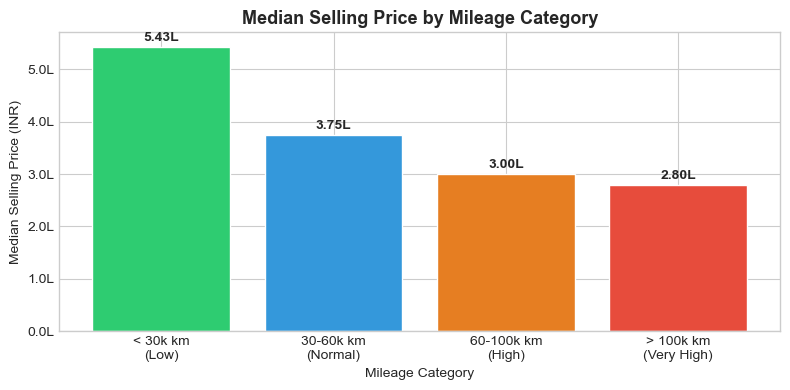

In [43]:
corr_age = df_eda['car_age'].corr(df_eda['selling_price'])
corr_km  = df_eda['km_driven'].corr(df_eda['selling_price'])

corr_table = pd.DataFrame({
    'Feature': ['Car Age', 'km_driven'],
    'Pearson Correlation with Selling Price': [f'{corr_age:.3f}', f'{corr_km:.3f}']
})
display(corr_table)

km_bins   = [0, 30_000, 60_000, 100_000, int(df_eda['km_driven'].max()) + 1]
km_labels = ['< 30k km\n(Low)', '30-60k km\n(Normal)', '60-100k km\n(High)', '> 100k km\n(Very High)']
df_eda['km_cat'] = pd.cut(df_eda['km_driven'], bins=km_bins, labels=km_labels)
km_median = df_eda.groupby('km_cat', observed=True)['selling_price'].median()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(km_median.index, km_median.values,
              color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'], edgecolor='white')
for bar, val in zip(bars, km_median.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f'{val/1e5:.2f}L', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Median Selling Price by Mileage Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Mileage Category')
ax.set_ylabel('Median Selling Price (INR)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))
plt.tight_layout()
plt.show()

#### Insight 3: Automatic vs Manual — Value Retention

,count,median,mean,median_L
transmission,,,,
Automatic,448,950000.0,1408154.0,9.5L
Manual,3892,325000.0,400067.0,3.25L


Automatic / Manual median price ratio: 2.92x


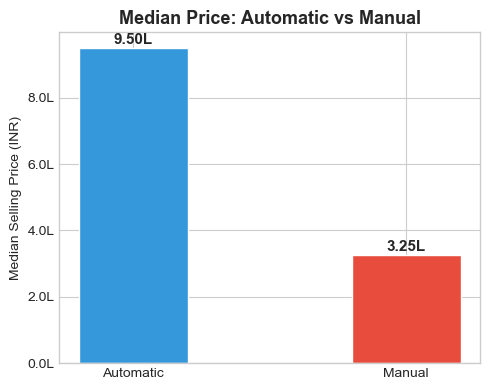

In [44]:
price_trans = df_eda.groupby('transmission')['selling_price'].agg(
    count='count', median='median', mean='mean'
).round(0)
price_trans['median_L'] = (price_trans['median'] / 1e5).round(2).astype(str) + 'L'
display(price_trans)

ratio = price_trans.loc['Automatic', 'median'] / price_trans.loc['Manual', 'median']
print(f'Automatic / Manual median price ratio: {ratio:.2f}x')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(price_trans.index, price_trans['median'],
              color=['#3498db', '#e74c3c'], edgecolor='white', width=0.4)
for bar, val in zip(bars, price_trans['median']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3000,
            f'{val/1e5:.2f}L', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Median Price: Automatic vs Manual', fontsize=13, fontweight='bold')
ax.set_ylabel('Median Selling Price (INR)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))
plt.tight_layout()
plt.show()

#### Insight 4: Fuel Type vs Resale Price

,count,median,mean,median_L
fuel,,,,
Diesel,2153,500000.0,669094.0,5.0L
Electric,1,310000.0,310000.0,3.1L
Petrol,2123,269000.0,344840.0,2.69L
CNG,40,247500.0,277175.0,2.48L
LPG,23,180000.0,167826.0,1.8L


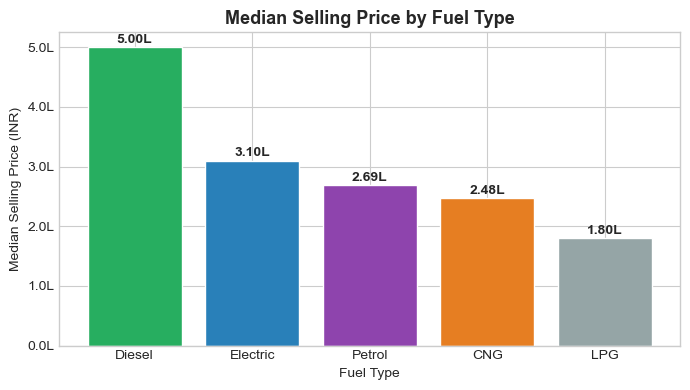

In [45]:
fuel_stats = (df_eda.groupby('fuel')['selling_price']
                    .agg(count='count', median='median', mean='mean')
                    .sort_values('median', ascending=False)
                    .round(0))
fuel_stats['median_L'] = (fuel_stats['median'] / 1e5).round(2).astype(str) + 'L'
display(fuel_stats)

fig, ax = plt.subplots(figsize=(7, 4))
palette = ['#27ae60', '#2980b9', '#8e44ad', '#e67e22', '#95a5a6']
bars = ax.bar(fuel_stats.index, fuel_stats['median'],
              color=palette[:len(fuel_stats)], edgecolor='white')
for bar, val in zip(bars, fuel_stats['median']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f'{val/1e5:.2f}L', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Median Selling Price by Fuel Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Median Selling Price (INR)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))
plt.tight_layout()
plt.show()

#### Insight 5: Non-Linearity - Why Linear Regression Is Insufficient

,Transformation,Skewness
0,Raw (selling_price),4.89
1,log1p(selling_price),0.06


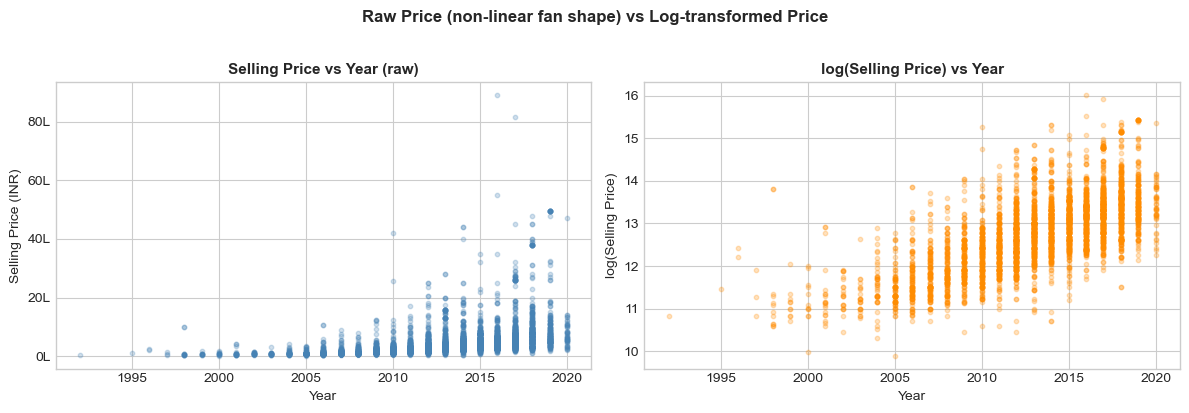

Coefficient of Variation (%) of Selling Price per Manufacturing Year:


,cv_%
year,
2011,73.8
2012,85.2
2013,83.0
2014,93.1
2015,63.4
2016,101.9
2017,88.9
2018,90.6
2019,106.4


In [46]:
# Skewness of target variable
skew_raw = df_eda['selling_price'].skew()
skew_log = np.log1p(df_eda['selling_price']).skew()

skew_table = pd.DataFrame({
    'Transformation': ['Raw (selling_price)', 'log1p(selling_price)'],
    'Skewness': [round(skew_raw, 2), round(skew_log, 2)]
})
display(skew_table)

# Scatter plots: raw vs log scale
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df_eda['year'], df_eda['selling_price'], alpha=0.25, s=10, color='steelblue')
axes[0].set_title('Selling Price vs Year (raw)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Selling Price (INR)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))

axes[1].scatter(df_eda['year'], np.log1p(df_eda['selling_price']), alpha=0.25, s=10, color='darkorange')
axes[1].set_title('log(Selling Price) vs Year', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('log(Selling Price)')

plt.suptitle('Raw Price (non-linear fan shape) vs Log-transformed Price',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Coefficient of Variation per year — heteroscedasticity evidence
cv_by_year = df_eda.groupby('year')['selling_price'].agg(mean='mean', std='std')
cv_by_year['cv_%'] = (cv_by_year['std'] / cv_by_year['mean'] * 100).round(1)
print('Coefficient of Variation (%) of Selling Price per Manufacturing Year:')
display(cv_by_year[['cv_%']].tail(10))

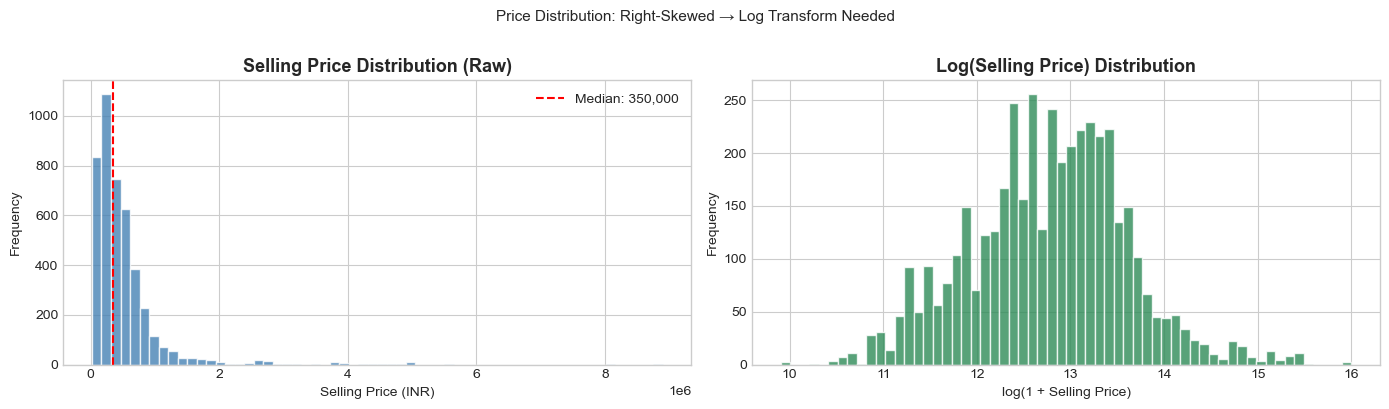

Insight: Price sangat right-skewed → log-transform wajib untuk semua model!


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['selling_price'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Selling Price Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Selling Price (INR)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['selling_price'].median(), color='red', linestyle='--', label=f'Median: {df["selling_price"].median():,.0f}')
axes[0].legend()

axes[1].hist(np.log1p(df['selling_price']), bins=60, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('Log(Selling Price) Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Selling Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Price Distribution: Right-Skewed → Log Transform Needed', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('eda_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Price sangat right-skewed → log-transform wajib untuk semua model!")

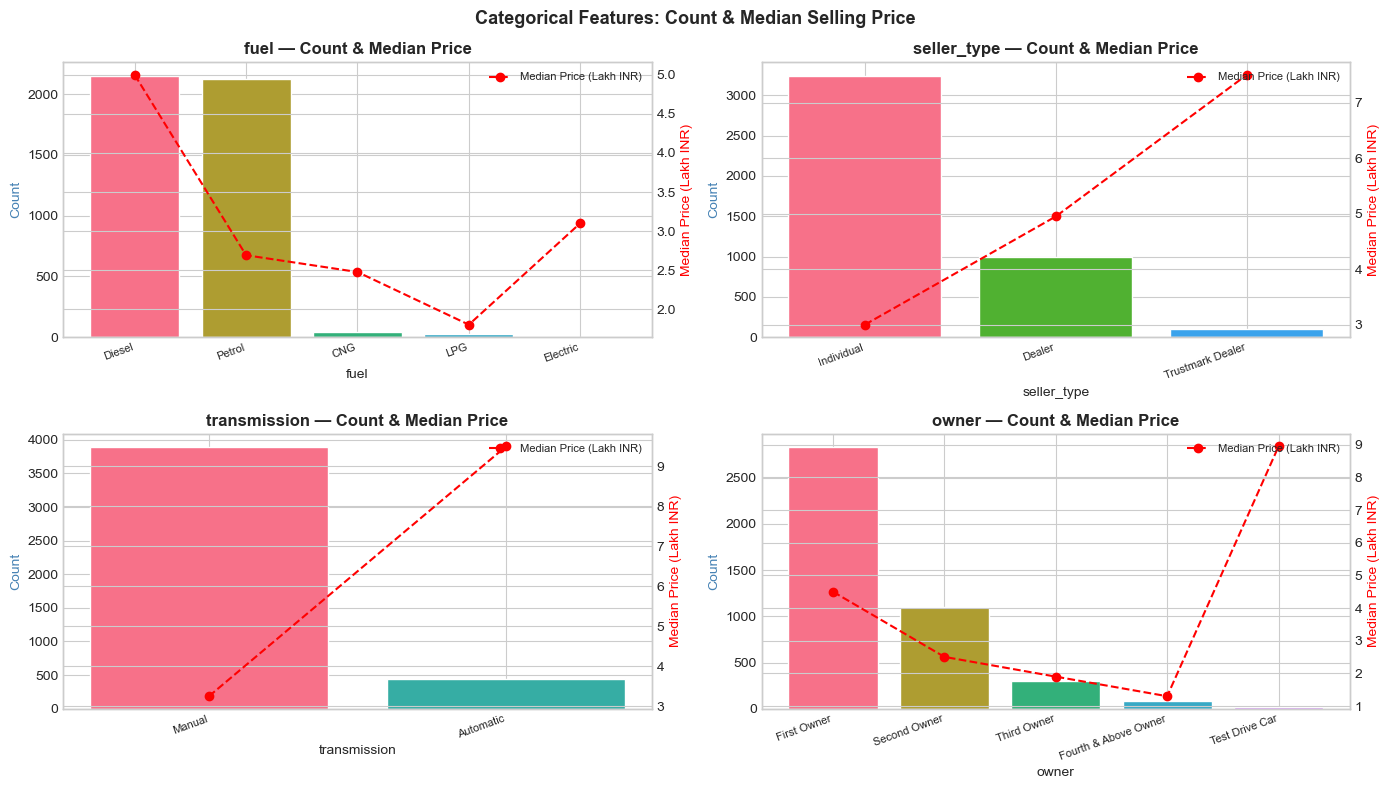

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ['fuel', 'seller_type', 'transmission', 'owner']):
    counts = df[col].value_counts()
    medians = df.groupby(col)['selling_price'].median().reindex(counts.index)
    bars = ax.bar(counts.index, counts.values, color=sns.color_palette('husl', len(counts)), edgecolor='white')
    ax.set_title(f'{col} — Count & Median Price', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count', color='steelblue')
    ax2 = ax.twinx()
    ax2.plot(range(len(counts)), medians.values / 1e5, 'r--o', ms=6, label='Median Price (Lakh INR)')
    ax2.set_ylabel('Median Price (Lakh INR)', color='red')
    ax2.legend(loc='upper right', fontsize=8)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=20, ha='right', fontsize=8)
plt.suptitle('Categorical Features: Count & Median Selling Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

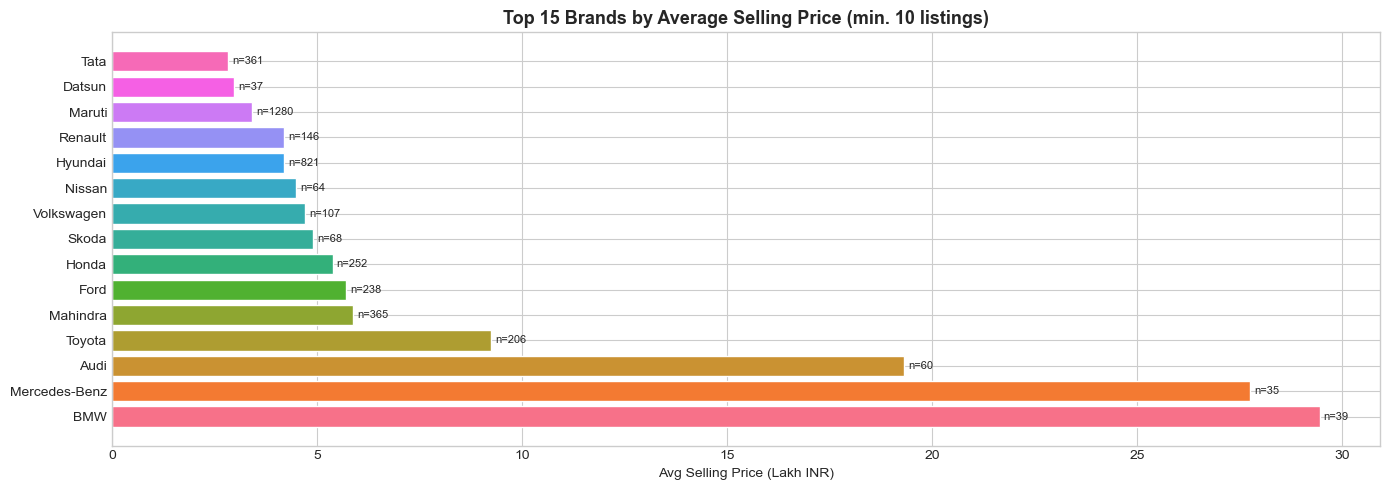

In [49]:
# Top 15 brands by average selling price
df['brand'] = df['name'].str.split().str[0]
brand_price = df.groupby('brand')['selling_price'].agg(['mean','count']).reset_index()
brand_price = brand_price[brand_price['count'] >= 10].sort_values('mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(brand_price['brand'], brand_price['mean'] / 1e5,
               color=sns.color_palette('husl', 15), edgecolor='white')
ax.set_xlabel('Avg Selling Price (Lakh INR)')
ax.set_title('Top 15 Brands by Average Selling Price (min. 10 listings)', fontsize=13, fontweight='bold')
for bar, count in zip(bars, brand_price['count']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'n={count}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('eda_brand_price.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['brand'], inplace=True)

## 4. Feature Engineering

In [50]:
df_proc = df.copy()

# 1. Brand+model (2 words)
df_proc['brand_model'] = df_proc['name'].apply(lambda x: ' '.join(x.split()[:2]))

# 2. Car age 
df_proc['car_age'] = 2026 - df_proc['year']

# 3. Interaction features
df_proc['km_per_year'] = df_proc['km_driven'] / (df_proc['car_age'] + 1)
df_proc['age_x_km']    = df_proc['car_age'] * df_proc['km_driven']

print("Features created:")
print(df_proc.dtypes)
print(f"\nShape: {df_proc.shape}")

Features created:
name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
brand_model       object
car_age            int64
km_per_year      float64
age_x_km           int64
dtype: object

Shape: (4340, 12)


## 5. Outlier Removal

**Method**: Percentile 1–99 on `selling_price`. Removes extreme luxury/damaged cars that are statistical outliers and would confuse the model.

Outlier removal (Percentile 1-99):
  Threshold: [55,000, 3,200,000] INR
  Removed: 85 rows (2.0%)
  Remaining: 4255 rows


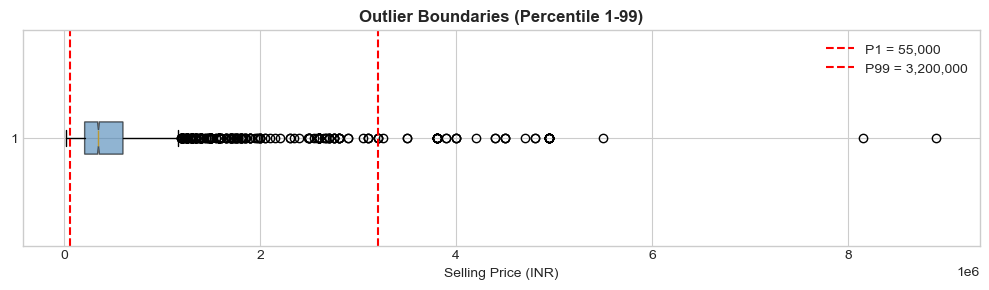

In [51]:
# Outlier removal using percentile 1-99
p01 = df_proc['selling_price'].quantile(0.01)
p99 = df_proc['selling_price'].quantile(0.99)

before = len(df_proc)
df_proc = df_proc[(df_proc['selling_price'] >= p01) & (df_proc['selling_price'] <= p99)].copy()
removed = before - len(df_proc)

print(f"Outlier removal (Percentile 1-99):")
print(f"  Threshold: [{p01:,.0f}, {p99:,.0f}] INR")
print(f"  Removed: {removed} rows ({removed/before*100:.1f}%)")
print(f"  Remaining: {len(df_proc)} rows")

fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(df['selling_price'], vert=False, notch=True, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.axvline(p01, color='red', linestyle='--', label=f'P1 = {p01:,.0f}')
ax.axvline(p99, color='red', linestyle='--', label=f'P99 = {p99:,.0f}')
ax.set_title('Outlier Boundaries (Percentile 1-99)', fontweight='bold')
ax.set_xlabel('Selling Price (INR)')
ax.legend()
plt.tight_layout()
plt.show()

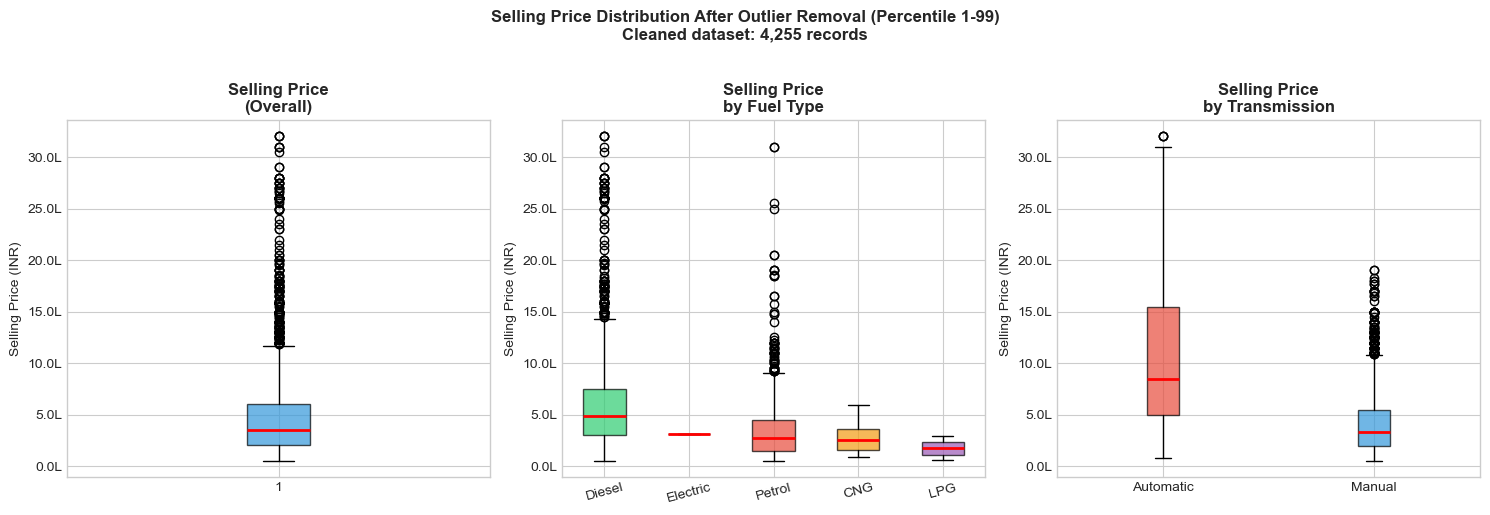

In [53]:
# Boxplot: Selling Price Distribution (Already Cleaned - Percentile 1-99)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Overall selling price
axes[0].boxplot(df_proc['selling_price'], patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', lw=2))
axes[0].set_title('Selling Price\n(Overall)', fontweight='bold')
axes[0].set_ylabel('Selling Price (INR)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))

# 2. By Fuel Type
fuel_order = df_proc.groupby('fuel')['selling_price'].median().sort_values(ascending=False).index
fuel_groups = [df_proc[df_proc['fuel'] == f]['selling_price'] for f in fuel_order]
bp = axes[1].boxplot(fuel_groups, labels=fuel_order, patch_artist=True,
                     medianprops=dict(color='red', lw=2))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Selling Price\nby Fuel Type', fontweight='bold')
axes[1].set_ylabel('Selling Price (INR)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))
axes[1].tick_params(axis='x', rotation=15)

# 3. By Transmission
trans_order = df_proc.groupby('transmission')['selling_price'].median().sort_values(ascending=False).index
trans_groups = [df_proc[df_proc['transmission'] == t]['selling_price'] for t in trans_order]
bp2 = axes[2].boxplot(trans_groups, labels=trans_order, patch_artist=True,
                      medianprops=dict(color='red', lw=2))
for patch, color in zip(bp2['boxes'], ['#e74c3c', '#3498db']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Selling Price\nby Transmission', fontweight='bold')
axes[2].set_ylabel('Selling Price (INR)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))

plt.suptitle(f'Selling Price Distribution After Outlier Removal (Percentile 1-99)\n'
             f'Cleaned dataset: {len(df_proc):,} records',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Train / Validation / Test Split

**Important**: Split *before* encoding to prevent data leakage. Encoding is fit **only on train set**, then applied to val/test.

Split ratio: **60% Train / 20% Val / 20% Test** (stratified by random_state=42)

In [54]:
df_proc = df_proc.drop(columns=['name', 'year'])
X = df_proc.drop('selling_price', axis=1)
y_orig = df_proc['selling_price']
y_log  = np.log1p(y_orig)

# Step 1: Hold-out 20% as test
X_temp, X_test, y_temp, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
# Step 2: Split remaining 80% → 75% train, 25% val (= 60%/20% overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

y_train_orig = np.expm1(y_train)
y_val_orig   = np.expm1(y_val)
y_test_orig  = np.expm1(y_test)

print(f"Split Summary:")
print(f"  Total  : {len(X):,} rows")
print(f"  Train  : {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Val    : {len(X_val):,} rows   ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test   : {len(X_test):,} rows   ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nTarget (selling_price) summary:")
print(y_train_orig.describe().round(0))

Split Summary:
  Total  : 4,255 rows
  Train  : 2,553 rows (60%)
  Val    : 851 rows   (20%)
  Test   : 851 rows   (20%)

Target (selling_price) summary:
count       2553.0
mean      474278.0
std       412348.0
min        55000.0
25%       210000.0
50%       365000.0
75%       600000.0
max      3200000.0
Name: selling_price, dtype: float64


## 7. Preprocessing (fit on Train only)

In [11]:
# A. Ordinal Encoding for 'owner'
owner_order = [['Test Drive Car', 'Fourth & Above Owner', 'Third Owner', 'Second Owner', 'First Owner']]
oe_owner = OrdinalEncoder(categories=owner_order, handle_unknown='use_encoded_value', unknown_value=-1)

X_train['owner_enc'] = oe_owner.fit_transform(X_train[['owner']])
X_val['owner_enc']   = oe_owner.transform(X_val[['owner']])
X_test['owner_enc']  = oe_owner.transform(X_test[['owner']])

for ds in [X_train, X_val, X_test]:
    ds.drop('owner', axis=1, inplace=True)

print("Owner encoding mapping:")
for i, cat in enumerate(oe_owner.categories_[0]):
    print(f"  {i} → {cat}")

Owner encoding mapping:
  0 → Test Drive Car
  1 → Fourth & Above Owner
  2 → Third Owner
  3 → Second Owner
  4 → First Owner


In [12]:
# B. Frequency Encoding for 'brand_model'
brand_freq_map = X_train['brand_model'].value_counts(normalize=True)

X_train['brand_freq'] = X_train['brand_model'].map(brand_freq_map).fillna(0)
X_val['brand_freq']   = X_val['brand_model'].map(brand_freq_map).fillna(0)
X_test['brand_freq']  = X_test['brand_model'].map(brand_freq_map).fillna(0)

for ds in [X_train, X_val, X_test]:
    ds.drop('brand_model', axis=1, inplace=True)

print(f"Brand frequency map: {len(brand_freq_map)} unique brands")
print(f"\nTop 10 most frequent brand+models:")
print(brand_freq_map.head(10).to_string())

Brand frequency map: 164 unique brands

Top 10 most frequent brand+models:
brand_model
Maruti Swift        0.082256
Maruti Alto         0.058363
Maruti Wagon        0.039170
Hyundai i20         0.028594
Hyundai Santro      0.028594
Hyundai Verna       0.027810
Tata Indica         0.026635
Toyota Innova       0.025852
Hyundai Grand       0.025460
Mahindra Scorpio    0.023502


In [13]:
# C. One-Hot Encoding for nominal categoricals
cat_cols = ['fuel', 'seller_type', 'transmission']
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=False, dtype=int)
X_val   = pd.get_dummies(X_val,   columns=cat_cols, drop_first=False, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=False, dtype=int)

# Align columns: val/test must match train's columns exactly
ref_cols = X_train.columns.tolist()
X_val    = X_val.reindex(columns=ref_cols, fill_value=0)
X_test   = X_test.reindex(columns=ref_cols, fill_value=0)

print(f"Final features ({len(ref_cols)}):")
for c in ref_cols:
    print(f"  - {c}")

Final features (15):
  - km_driven
  - car_age
  - km_per_year
  - age_x_km
  - owner_enc
  - brand_freq
  - fuel_CNG
  - fuel_Diesel
  - fuel_LPG
  - fuel_Petrol
  - seller_type_Dealer
  - seller_type_Individual
  - seller_type_Trustmark Dealer
  - transmission_Automatic
  - transmission_Manual


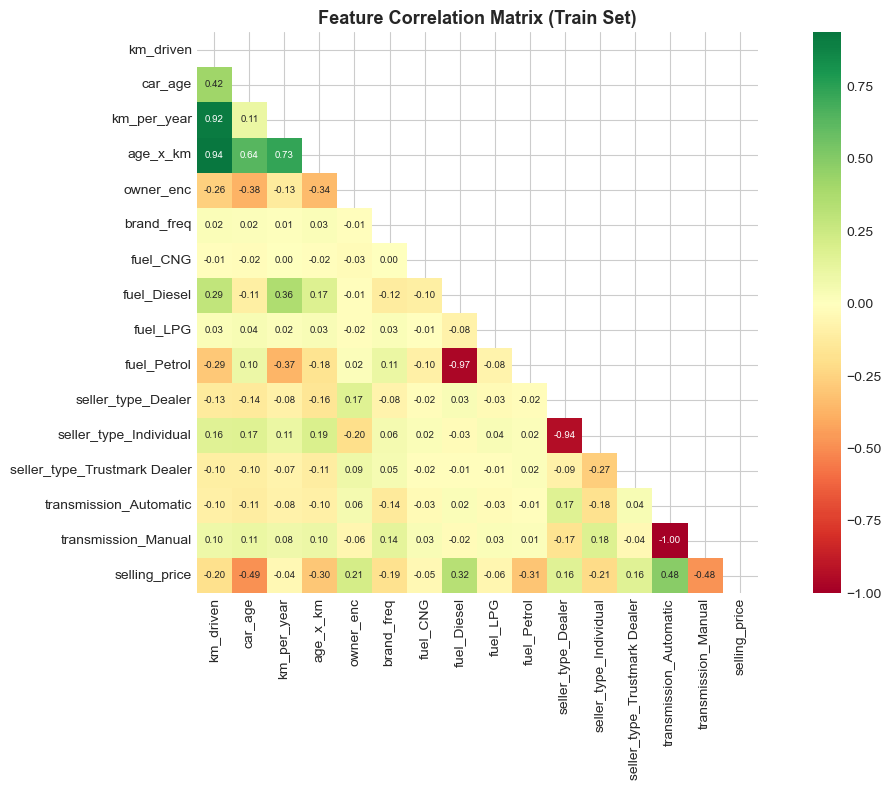

In [14]:
# Correlation heatmap after encoding
train_corr = X_train.copy()
train_corr['selling_price'] = y_train_orig.values

fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = train_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation Helper Function

In [15]:
all_results   = {}
all_test_pred = {}

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(name, model, X_tr=X_train, X_vl=X_val, X_te=X_test,
                   y_tr=y_train_orig, y_vl=y_val_orig, y_te=y_test_orig):
    pred_tr  = np.expm1(model.predict(X_tr))
    pred_vl  = np.expm1(model.predict(X_vl))
    pred_te  = np.expm1(model.predict(X_te))

    res = {
        'Train': {
            'R2':  r2_score(y_tr, pred_tr),
            'MAE': mean_absolute_error(y_tr, pred_tr),
            'RMSE': np.sqrt(mean_squared_error(y_tr, pred_tr)),
            'MAPE': mape(y_tr, pred_tr)
        },
        'Val': {
            'R2':  r2_score(y_vl, pred_vl),
            'MAE': mean_absolute_error(y_vl, pred_vl),
            'RMSE': np.sqrt(mean_squared_error(y_vl, pred_vl)),
            'MAPE': mape(y_vl, pred_vl)
        },
        'Test': {
            'R2':  r2_score(y_te, pred_te),
            'MAE': mean_absolute_error(y_te, pred_te),
            'RMSE': np.sqrt(mean_squared_error(y_te, pred_te)),
            'MAPE': mape(y_te, pred_te)
        }
    }

    gap = res['Train']['R2'] - res['Test']['R2']
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  {'Metric':<12} {'Train':>12} {'Val':>12} {'Test':>12}")
    print(f"  {'-'*50}")
    print(f"  {'R2':<12} {res['Train']['R2']:>12.4f} {res['Val']['R2']:>12.4f} {res['Test']['R2']:>12.4f}")
    print(f"  {'MAE':<12} {res['Train']['MAE']:>12,.0f} {res['Val']['MAE']:>12,.0f} {res['Test']['MAE']:>12,.0f}")
    print(f"  {'RMSE':<12} {res['Train']['RMSE']:>12,.0f} {res['Val']['RMSE']:>12,.0f} {res['Test']['RMSE']:>12,.0f}")
    print(f"  {'MAPE':<12} {res['Train']['MAPE']:>11.2f}% {res['Val']['MAPE']:>11.2f}% {res['Test']['MAPE']:>11.2f}%")
    print(f"  Overfit gap (Train - Test R2): {gap:.4f}  {'[OK]' if gap < 0.15 else '[OVERFIT]'}")

    all_results[name]   = res
    all_test_pred[name] = pred_te
    return res, pred_te

print("Evaluation function defined!")

Evaluation function defined!


## 9. Model Training & Evaluation

### 9a. Linear Regression (Baseline)


In [16]:
# No hyperparameters → direct fit
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_results, lin_pred = evaluate_model('Linear Regression', lin_model)

# 5-fold CV untuk verifikasi
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(LinearRegression(), X_train, y_train, cv=kf, scoring='r2')
print(f"\n5-Fold CV R2 scores: {cv_r2.round(4)}")
print(f"Mean CV R2: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")


  Linear Regression
  Metric              Train          Val         Test
  --------------------------------------------------
  R2                 0.5771       0.5155       0.5908
  MAE               161,075      158,836      162,436
  RMSE              268,095      274,500      267,763
  MAPE               37.30%       38.14%       39.83%
  Overfit gap (Train - Test R2): -0.0136  [OK]

5-Fold CV R2 scores: [0.7052 0.6613 0.6301 0.7007 0.6449]
Mean CV R2: 0.6685 (+/- 0.0299)


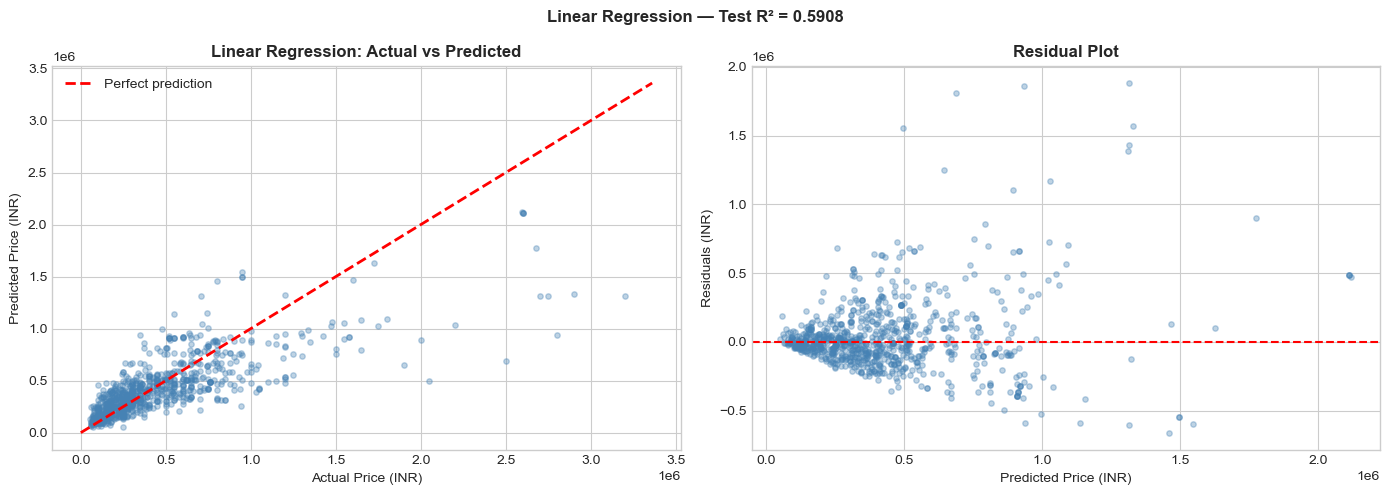

In [17]:
# Residual plot for Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_orig, lin_pred, alpha=0.35, color='steelblue', s=15)
lim = max(y_test_orig.max(), lin_pred.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (INR)')
axes[0].set_ylabel('Predicted Price (INR)')
axes[0].set_title('Linear Regression: Actual vs Predicted', fontweight='bold')
axes[0].legend()

residuals = y_test_orig - lin_pred
axes[1].scatter(lin_pred, residuals, alpha=0.35, color='steelblue', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Price (INR)')
axes[1].set_ylabel('Residuals (INR)')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.suptitle(f'Linear Regression — Test R² = {lin_results["Test"]["R2"]:.4f}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('linreg_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

### 9b. Ridge Regression (RidgeCV)

In [18]:
# RidgeCV: built-in LOO-CV across 200 alpha candidates — mathematically optimal
alphas_ridge = np.logspace(-3, 4, 200)
ridge_model = RidgeCV(alphas=alphas_ridge, cv=10, scoring='r2')
ridge_model.fit(X_train, y_train)

print(f"RidgeCV selected alpha: {ridge_model.alpha_:.6f}")
print(f"Best CV R2: {ridge_model.best_score_:.4f}")
ridge_results, ridge_pred = evaluate_model('Ridge (RidgeCV)', ridge_model)

RidgeCV selected alpha: 0.038275
Best CV R2: 0.6684

  Ridge (RidgeCV)
  Metric              Train          Val         Test
  --------------------------------------------------
  R2                 0.5768       0.5153       0.5906
  MAE               161,091      158,853      162,398
  RMSE              268,201      274,567      267,833
  MAPE               37.29%       38.13%       39.80%
  Overfit gap (Train - Test R2): -0.0138  [OK]


### 9c. Lasso Regression (LassoCV)


In [19]:
# LassoCV: coordinate descent path across 200 alpha candidates
alphas_lasso = np.logspace(-5, 1, 200)
lasso_model = LassoCV(alphas=alphas_lasso, cv=10, max_iter=10000, random_state=42, n_jobs=-1)
lasso_model.fit(X_train, y_train)

print(f"LassoCV selected alpha: {lasso_model.alpha_:.8f}")

# Feature elimination analysis (Lasso can zero-out features)
coef_nonzero = np.sum(lasso_model.coef_ != 0)
print(f"Non-zero coefficients: {coef_nonzero} / {len(lasso_model.coef_)}")
if coef_nonzero < len(lasso_model.coef_):
    zeroed = [ref_cols[i] for i, c in enumerate(lasso_model.coef_) if c == 0]
    print(f"Features zeroed out: {zeroed}")

lasso_results, lasso_pred = evaluate_model('Lasso (LassoCV)', lasso_model)

LassoCV selected alpha: 0.00001000
Non-zero coefficients: 13 / 15
Features zeroed out: ['fuel_Petrol', 'seller_type_Dealer']

  Lasso (LassoCV)
  Metric              Train          Val         Test
  --------------------------------------------------
  R2                 0.5770       0.5154       0.5907
  MAE               161,081      158,870      162,427
  RMSE              268,136      274,528      267,797
  MAPE               37.29%       38.14%       39.82%
  Overfit gap (Train - Test R2): -0.0137  [OK]


### 9d. Random Forest (HalvingRandomSearchCV)


In [20]:
# HalvingRandomSearchCV for Random Forest - progressive elimination
param_dist_rf = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf':  [1, 2, 4, 6],
    'max_features':      [0.6, 0.7, 0.8, 1.0, 'sqrt'],
    'max_samples':       [0.7, 0.8, 0.9, None], 
}

rf_search = HalvingRandomSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_candidates=80,           
    factor=3,                  
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_

print(f"\nBest CV R2: {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")
rf_results, rf_pred = evaluate_model('Random Forest (HalvingSearch)', rf_model)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 6
min_resources_: 10
max_resources_: 2553
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 80
n_resources: 10
Fitting 5 folds for each of 80 candidates, totalling 400 fits
----------
iter: 1
n_candidates: 27
n_resources: 30
Fitting 5 folds for each of 27 candidates, totalling 135 fits
----------
iter: 2
n_candidates: 9
n_resources: 90
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 3
n_candidates: 3
n_resources: 270
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best CV R2: 0.6836
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 0.7, 'max_features': 0.8, 'max_depth': None}

  Random Forest (HalvingSearch)
  Metric              Train          Val         Test
  --------------------------------------------------
  R2                 0.9165       0.7225       0.7809
  MAE                61,375      113,979      1

### 9e. Gradient Boosting (HalvingRandomSearchCV)
**Tuning**: Sama dengan Random Forest, menggunakan `HalvingRandomSearchCV`. Gradient Boosting memiliki lebih banyak hyperparameter yang saling berinteraksi (learning_rate × n_estimators × max_depth), sehingga progressive halving sangat membantu menemukan kombinasi optimal.

In [21]:
# HalvingRandomSearchCV for Gradient Boosting
param_dist_gb = {
    'n_estimators':     [300, 400, 500, 600, 800],
    'learning_rate':    [0.02, 0.04, 0.06, 0.08, 0.10, 0.12],
    'max_depth':        [3, 4, 5, 6],
    'subsample':        [0.65, 0.75, 0.80, 0.85, 0.90],
    'min_samples_leaf': [2, 3, 5, 8, 10],
    'max_features':     [0.7, 0.8, 1.0, 'sqrt'],
}

gb_search = HalvingRandomSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_candidates=80,
    factor=3,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)
gb_search.fit(X_train, y_train)
gb_model = gb_search.best_estimator_

print(f'Best CV R2: {gb_search.best_score_:.4f}')
print(f'Best params: {gb_search.best_params_}')
gb_results, gb_pred = evaluate_model('Gradient Boosting (HalvingSearch)', gb_model)


n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 6
min_resources_: 10
max_resources_: 2553
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 80
n_resources: 10
Fitting 5 folds for each of 80 candidates, totalling 400 fits
----------
iter: 1
n_candidates: 27
n_resources: 30
Fitting 5 folds for each of 27 candidates, totalling 135 fits
----------
iter: 2
n_candidates: 9
n_resources: 90
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 3
n_candidates: 3
n_resources: 270
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best CV R2: 0.6958
Best params: {'subsample': 0.65, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': 1.0, 'max_depth': 4, 'learning_rate': 0.02}

  Gradient Boosting (HalvingSearch)
  Metric              Train          Val         Test
  --------------------------------------------------
  R2                 0.7861       0.6993       0.7669
  MAE               113,566      123,118      121

### 9f. HistGradientBoosting (RandomizedSearchCV + early_stopping)

In [22]:
# RandomizedSearchCV for HistGBR — only tune structural params, early_stopping handles n_iter
param_dist_hgbr = {
    'learning_rate':     [0.04, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20],
    'max_depth':         [3, 4, 5, 6, 7, None],
    'min_samples_leaf':  [5, 8, 10, 15, 20, 25, 30],
    'l2_regularization': [0.0, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0],
    'max_leaf_nodes':    [20, 25, 31, 40, 50, 63, None],
    'max_iter':          [500, 600, 800, 1000],  
}

hgbr_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(
        random_state=42,
        early_stopping=True,
        n_iter_no_change=25,       
        scoring='loss',
        validation_fraction=0.15,  
        tol=1e-5
    ),
    param_distributions=param_dist_hgbr,
    n_iter=100,                   
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)
hgbr_search.fit(X_train, y_train)
hgbr_model = hgbr_search.best_estimator_

print(f"\nBest CV R2: {hgbr_search.best_score_:.4f}")
print(f"Best params: {hgbr_search.best_params_}")
print(f"n_iter_ (actual trees used via early stopping): {hgbr_model.n_iter_}")
hgbr_results, hgbr_pred = evaluate_model('HistGradBoost (RandomizedSearch)', hgbr_model)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best CV R2: 0.8152
Best params: {'min_samples_leaf': 5, 'max_leaf_nodes': 25, 'max_iter': 500, 'max_depth': None, 'learning_rate': 0.06, 'l2_regularization': 2.0}
n_iter_ (actual trees used via early stopping): 171

  HistGradBoost (RandomizedSearch)
  Metric              Train          Val         Test
  --------------------------------------------------
  R2                 0.8649       0.7379       0.7906
  MAE                86,159      110,520      111,120
  RMSE              151,549      201,894      191,547
  MAPE               19.25%       27.36%       27.38%
  Overfit gap (Train - Test R2): 0.0743  [OK]


## 10. Error Analysis - Best Model So Far

Current best model: HistGradBoost (RandomizedSearch)
Test R2: 0.7906


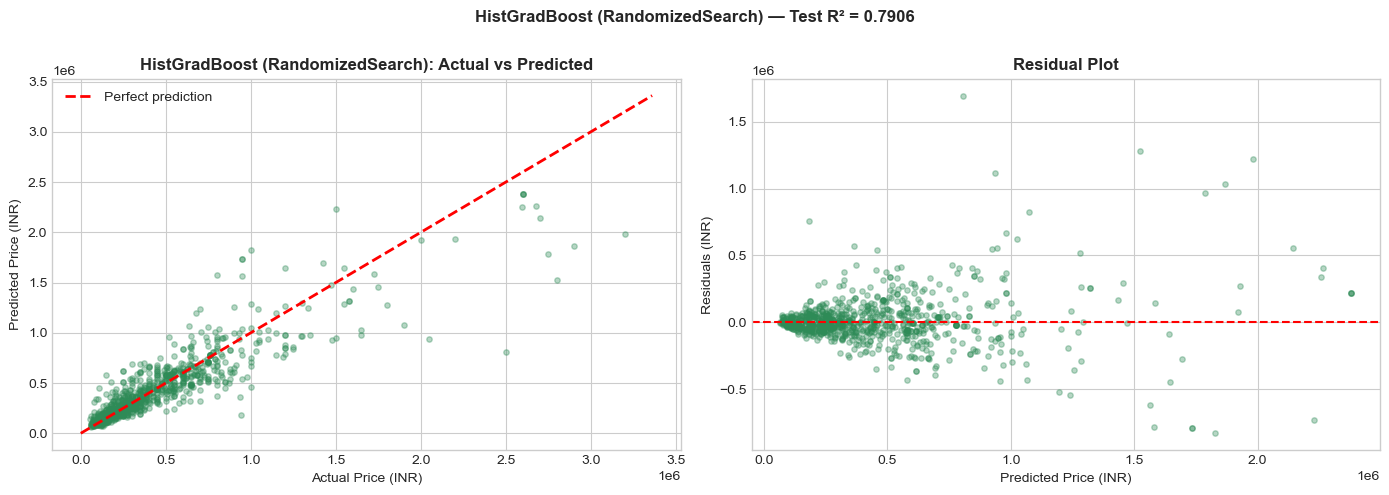

In [23]:
best_name = max(all_results, key=lambda k: all_results[k]['Test']['R2'])
best_pred = all_test_pred[best_name]
print(f"Current best model: {best_name}")
print(f"Test R2: {all_results[best_name]['Test']['R2']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_orig, best_pred, alpha=0.35, color='seagreen', s=15)
lim = max(y_test_orig.max(), best_pred.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (INR)')
axes[0].set_ylabel('Predicted Price (INR)')
axes[0].set_title(f'{best_name}: Actual vs Predicted', fontweight='bold')
axes[0].legend()

residuals = y_test_orig - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.35, color='seagreen', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Price (INR)')
axes[1].set_ylabel('Residuals (INR)')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.suptitle(f'{best_name} — Test R² = {all_results[best_name]["Test"]["R2"]:.4f}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

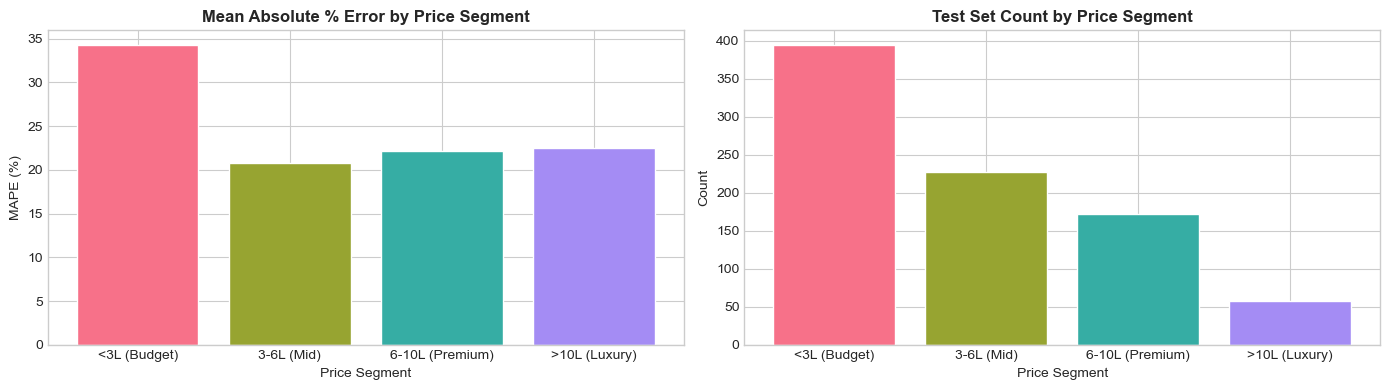


Error by segment:
                 count   mean    std   min    25%    50%    75%     max
price_range                                                            
<3L (Budget)     394.0  34.21  41.46  0.00  10.93  22.73  40.65  313.22
3-6L (Mid)       228.0  20.75  18.17  0.10   8.91  16.35  27.10   98.06
6-10L (Premium)  172.0  22.12  19.51  0.02   6.93  16.27  30.69   97.47
>10L (Luxury)     57.0  22.54  14.74  0.19  11.85  18.34  34.06   67.75


In [24]:
# Error by price range
error_df = X_test.copy()
error_df['actual']    = y_test_orig.values
error_df['predicted'] = best_pred
error_df['abs_err']   = abs(error_df['actual'] - error_df['predicted'])
error_df['pct_err']   = error_df['abs_err'] / error_df['actual'] * 100

bins   = [0, 300000, 600000, 1000000, float('inf')]
labels = ['<3L (Budget)', '3-6L (Mid)', '6-10L (Premium)', '>10L (Luxury)']
error_df['price_range'] = pd.cut(error_df['actual'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
price_err = error_df.groupby('price_range', observed=True)['pct_err'].mean()
price_cnt = error_df.groupby('price_range', observed=True).size()

axes[0].bar(price_err.index, price_err.values, color=sns.color_palette('husl', 4), edgecolor='white')
axes[0].set_title('Mean Absolute % Error by Price Segment', fontweight='bold')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xlabel('Price Segment')

axes[1].bar(price_cnt.index, price_cnt.values, color=sns.color_palette('husl', 4), edgecolor='white')
axes[1].set_title('Test Set Count by Price Segment', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Price Segment')

plt.tight_layout()
plt.show()
print("\nError by segment:")
print(error_df.groupby('price_range', observed=True)['pct_err'].describe().round(2))

In [55]:
# Feature Importance
fi_model = {'HistGradBoost (RandomizedSearch)': hgbr_model,
            'Random Forest (HalvingSearch)': rf_model,
            'Gradient Boosting (HalvingSearch)': gb_model}.get(best_name, hgbr_model)

if hasattr(fi_model, 'feature_importances_'):
    fi = pd.Series(fi_model.feature_importances_, index=ref_cols).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#2196F3' if i < 5 else '#90CAF9' for i in range(len(fi))]
    fi.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Importance')
    ax.set_xticklabels(fi.index, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(fi.to_string())

## 11. Full Model Comparison

In [26]:
rows = []
for name, res in all_results.items():
    gap = res['Train']['R2'] - res['Test']['R2']
    rows.append({
        'Model':      name,
        'Train R2':   round(res['Train']['R2'], 4),
        'Val R2':     round(res['Val']['R2'],   4),
        'Test R2':    round(res['Test']['R2'],  4),
        'Test MAE':   f"{res['Test']['MAE']:,.0f}",
        'Test RMSE':  f"{res['Test']['RMSE']:,.0f}",
        'Test MAPE':  f"{res['Test']['MAPE']:.2f}%",
        'Overfit Gap': round(gap, 4),
        'Status':     'OK' if gap < 0.15 else 'OVERFIT'
    })

comparison_df = pd.DataFrame(rows).sort_values('Test R2', ascending=False).reset_index(drop=True)
print("=== FULL MODEL COMPARISON (sorted by Test R2) ===")
print(comparison_df.to_string(index=False))

=== FULL MODEL COMPARISON (sorted by Test R2) ===
                            Model  Train R2  Val R2  Test R2 Test MAE Test RMSE Test MAPE  Overfit Gap Status
 HistGradBoost (RandomizedSearch)    0.8649  0.7379   0.7906  111,120   191,547    27.38%       0.0743     OK
    Random Forest (HalvingSearch)    0.9165  0.7225   0.7809  109,598   195,933    28.10%       0.1356     OK
Gradient Boosting (HalvingSearch)    0.7861  0.6993   0.7669  121,849   202,089    30.74%       0.0192     OK
                Linear Regression    0.5771  0.5155   0.5908  162,436   267,763    39.83%      -0.0136     OK
                  Lasso (LassoCV)    0.5770  0.5154   0.5907  162,427   267,797    39.82%      -0.0137     OK
                  Ridge (RidgeCV)    0.5768  0.5153   0.5906  162,398   267,833    39.80%      -0.0138     OK


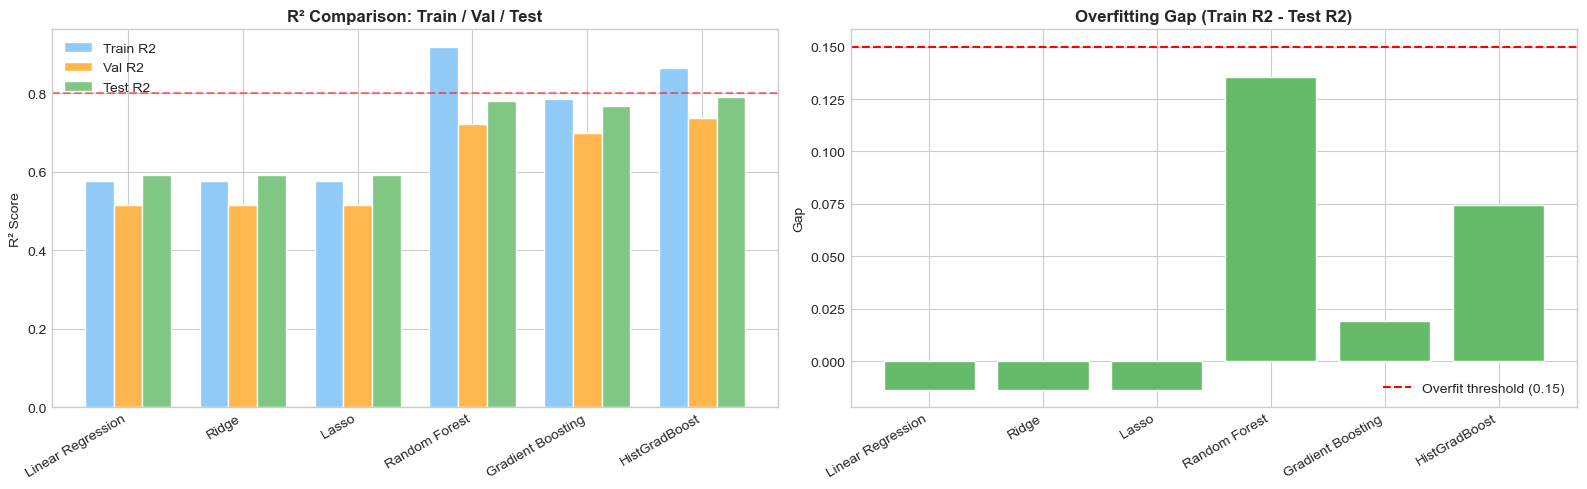

In [27]:
# Comparison bar charts
model_names  = list(all_results.keys())
test_r2_vals = [all_results[m]['Test']['R2']  for m in model_names]
val_r2_vals  = [all_results[m]['Val']['R2']   for m in model_names]
train_r2_vals= [all_results[m]['Train']['R2'] for m in model_names]
gap_vals     = [all_results[m]['Train']['R2'] - all_results[m]['Test']['R2'] for m in model_names]

x = np.arange(len(model_names))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R2 comparison
axes[0].bar(x - w, train_r2_vals, w, label='Train R2', color='#90CAF9', edgecolor='white')
axes[0].bar(x,     val_r2_vals,   w, label='Val R2',   color='#FFB74D', edgecolor='white')
axes[0].bar(x + w, test_r2_vals,  w, label='Test R2',  color='#81C784', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.split('(')[0].strip() for m in model_names], rotation=30, ha='right')
axes[0].set_title('R² Comparison: Train / Val / Test', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].legend()
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='R2=0.8 target')

# Overfitting gap
colors_gap = ['#EF5350' if g > 0.15 else '#66BB6A' for g in gap_vals]
axes[1].bar(x, gap_vals, color=colors_gap, edgecolor='white')
axes[1].axhline(0.15, color='red', linestyle='--', label='Overfit threshold (0.15)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.split('(')[0].strip() for m in model_names], rotation=30, ha='right')
axes[1].set_title('Overfitting Gap (Train R2 - Test R2)', fontweight='bold')
axes[1].set_ylabel('Gap')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Model Selection with Justification

**Composite Score Formula**: `0.60 × (Test R² / max_R²) + 0.40 × (1 − gap / max_gap)`

In [28]:
# Step 1 & 2: Filter candidates
candidates = {
    k: v for k, v in all_results.items()
    if v['Test']['R2'] >= 0.72 and (v['Train']['R2'] - v['Test']['R2']) <= 0.15
}
if not candidates:
    candidates = dict(sorted(all_results.items(), key=lambda x: -x[1]['Test']['R2'])[:3])

# Step 3: Rank by Test R2
print(f'  Candidates after filtering ({len(candidates)} models):')
print(f'  {"-"*70}')
for name, res in sorted(candidates.items(), key=lambda x: -x[1]['Test']['R2']):
    gap = res['Train']['R2'] - res['Test']['R2']
    print(f'  {name:<42} TestR2={res["Test"]["R2"]:.4f}  GAP={gap:.4f}  MAE={res["Test"]["MAE"]:,.0f}')

best_name = max(candidates, key=lambda k: candidates[k]['Test']['R2'])
best_res  = all_results[best_name]
gap_best  = best_res['Train']['R2'] - best_res['Test']['R2']

print()
print('='*60)
print(f'  WINNER: {best_name}')
print(f'  Test R2:   {best_res["Test"]["R2"]:.4f}  (highest among filtered candidates)')
print(f'  Test MAE:  {best_res["Test"]["MAE"]:,.0f} INR')
print(f'  Test MAPE: {best_res["Test"]["MAPE"]:.2f}%')
print(f'  Gap:       {gap_best:.4f}  (acceptable, well below 0.15 threshold)')
print()



  Candidates after filtering (3 models):
  ----------------------------------------------------------------------
  HistGradBoost (RandomizedSearch)           TestR2=0.7906  GAP=0.0743  MAE=111,120
  Random Forest (HalvingSearch)              TestR2=0.7809  GAP=0.1356  MAE=109,598
  Gradient Boosting (HalvingSearch)          TestR2=0.7669  GAP=0.0192  MAE=121,849

  WINNER: HistGradBoost (RandomizedSearch)
  Test R2:   0.7906  (highest among filtered candidates)
  Test MAE:  111,120 INR
  Test MAPE: 27.38%
  Gap:       0.0743  (acceptable, well below 0.15 threshold)



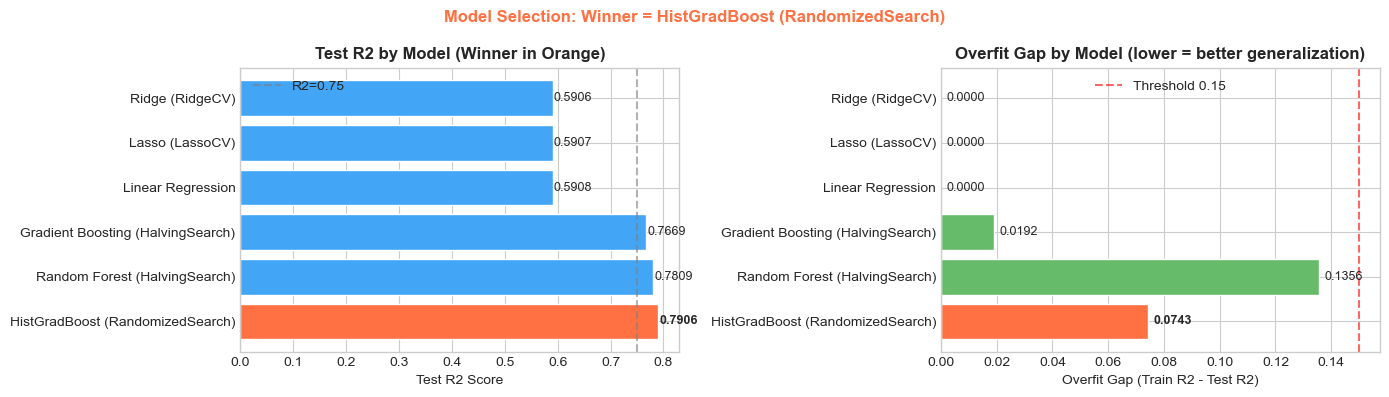

In [29]:
# Visualization: Model Comparison by Test R2 and Gap
sorted_models = sorted(all_results.keys(),
    key=lambda k: all_results[k]['Test']['R2'], reverse=True)

test_r2s = [all_results[m]['Test']['R2'] for m in sorted_models]
gaps     = [max(0, all_results[m]['Train']['R2'] - all_results[m]['Test']['R2']) for m in sorted_models]
colors_bar = ['#FF7043' if m == best_name else '#42A5F5' for m in sorted_models]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar 1: Test R2
axes[0].barh(sorted_models, test_r2s, color=colors_bar, edgecolor='white')
axes[0].axvline(0.75, color='gray', linestyle='--', alpha=0.6, label='R2=0.75')
for i, (m, v) in enumerate(zip(sorted_models, test_r2s)):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center',
                 fontweight='bold' if m == best_name else 'normal', fontsize=9)
axes[0].set_xlabel('Test R2 Score')
axes[0].set_title('Test R2 by Model (Winner in Orange)', fontweight='bold')
axes[0].legend()

# Bar 2: Overfit gap
colors_gap = ['#EF5350' if g > 0.15 else '#FF7043' if m == best_name else '#66BB6A'
              for m, g in zip(sorted_models, gaps)]
axes[1].barh(sorted_models, gaps, color=colors_gap, edgecolor='white')
axes[1].axvline(0.15, color='red', linestyle='--', alpha=0.6, label='Threshold 0.15')
for i, (m, v) in enumerate(zip(sorted_models, gaps)):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center',
                 fontweight='bold' if m == best_name else 'normal', fontsize=9)
axes[1].set_xlabel('Overfit Gap (Train R2 - Test R2)')
axes[1].set_title('Overfit Gap by Model (lower = better generalization)', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Model Selection: Winner = {best_name}', fontsize=12, fontweight='bold', color='#FF7043')
plt.tight_layout()
plt.show()


## 13. Save Best Model

In [30]:
best_model_objects = {
    'Linear Regression':                    lin_model,
    'Ridge (RidgeCV)':                      ridge_model,
    'Lasso (LassoCV)':                      lasso_model,
    'Random Forest (HalvingSearch)':        rf_model,
    'Gradient Boosting (HalvingSearch)':    gb_model,
    'HistGradBoost (RandomizedSearch)':     hgbr_model,
}

best_model_obj = best_model_objects[best_name]

joblib.dump(best_model_obj, '../../../best_model.pkl')
joblib.dump(oe_owner,       '../../../ordinal_encoder.pkl')
joblib.dump(brand_freq_map, '../../../brand_freq_map.pkl')
joblib.dump(ref_cols,       '../../../feature_columns.pkl')

import os
web_app_dir = '../web_app'
if os.path.exists(web_app_dir):
    joblib.dump(best_model_obj, f'{web_app_dir}/best_model.pkl')
    joblib.dump(oe_owner,       f'{web_app_dir}/ordinal_encoder.pkl')
    joblib.dump(brand_freq_map, f'{web_app_dir}/brand_freq_map.pkl')
    joblib.dump(ref_cols,       f'{web_app_dir}/feature_columns.pkl')
    print(f"Also saved to {web_app_dir}/")

print(f"Saved: best_model.pkl ({best_name})")
print(f"Saved: ordinal_encoder.pkl, brand_freq_map.pkl, feature_columns.pkl")
print(f"\nModel type: {type(best_model_obj).__name__}")

Also saved to ../web_app/
Saved: best_model.pkl (HistGradBoost (RandomizedSearch))
Saved: ordinal_encoder.pkl, brand_freq_map.pkl, feature_columns.pkl

Model type: HistGradientBoostingRegressor
